# HTF Threshold Optimization

## 1. Config

In [1]:
from __future__ import annotations
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# ----------------------------------------------------------------------------- paths
ROOT      = Path(".").resolve()                                                                
HTF_XLSX  = ROOT / "Inputs" / "HTF_Thresholds" / "HTF Threshold.xlsx"
MASTER    = ROOT / "Inputs" / "Flood_Reference_Data" / "htf_master.csv"
NWM_TREE  = ROOT / "Inputs" / "NWM_Data" / "twl_buffer5km_nwm_aa_top5"                                        
OUT_DIR   = Path("Outputs") / "Direct_Search";  OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------- modeling knobs
"""Datum in which the HTF threshold is compared against NWM TWL.
   CONFIRMED (data owner): HTF Threshold.xlsx is referenced to MHHW, so compare against
   value_m_mhhw. CAVEAT: the §8 reconciliation shows the NWM's MHHW sits systematically
   BELOW the threshold on gauge-confirmed flood days (~0.2-0.5 m) -- correct that offset
   before trusting the optimization, else theta just absorbs the bias.
"""

DATUM = "mhhw"  # -> when we select the mhhw, ituses NWM column 'value_m_mhhw'
DATUM_COL = {
    "mhhw": "value_m_mhhw",
    "navd88": "value_m_navd88"
    }[DATUM]

# How to collapse the hourly TWL series to one value per day.
DAILY_REDUCE = "max"                 # daily peak water level (the HTF-relevant statistic)

# Which observed-flood sources define a "flood occurred" label, and which define a
# trustworthy "no flood" (explicit 0).
#   LANCE is EXCLUDED from both roles: 'flood_detected_Lance' fires on ~56% of the days it observes,
#   implausible for HTF, and using its 0s as negatives while ignoring its 1s would assert
#   "no flood" on days it flagged. We lean on the reliable sources instead.
#   Groundsource only ever reports positives, so it can mark floods but never absence.
POSITIVE_SOURCES = ["flood_gfm", "flood_Groundsource", "TidsCurrents_minor"]
NEGATIVE_SOURCES = ["flood_gfm", "TidsCurrents_minor"]
# NOTE: 'flood_or_recurring_detected_Lance' is also excluded -- it is 1 for every non-null
# row (it counts recurring/permanent water), so it is not a flood label at all.

# Threshold search: evaluate at BREAKPOINTS -- the midpoints between consecutive sorted
# daily-peak TWL values (plus one candidate below the min and one above the max). The
# objective is piecewise-constant in theta and only changes when theta crosses an
# observed TWL value, so these midpoints realise *every* distinct classification
# exactly -- the optimum is found with no grid resolution to tune.
# CONSTRAIN_TO_RANGE clamps theta inside the ML [thr_low, thr_high]. That range is only
# ~0.1 m wide, but the §8 reconciliation shows theta needs to move ~0.35 m to match
# observed floods -- the clamp would block the very calibration this study is about.
# Keep it False; the resulting theta is an NWM-specific operational trigger (report the
# shift from the ML baseline as a result).
CONSTRAIN_TO_RANGE = False
EPS = 1e-6                           # nudge for the below-min / above-max candidates

# Guards against degenerate optima. Without them the search can return a theta that
# flags EVERY day or NO day -- not a calibration but an artefact, and it produces absurd
# thresholds (e.g. loc145 theta=+2.64 m, loc495 theta=-4.82 m). Where the evidence is too
# thin we ABSTAIN and keep the ML baseline rather than invent a number.
MIN_FLOOD_DAYS         = 5     # need this many observed floods to attempt calibration
REQUIRE_NON_DEGENERATE = True  # theta must flag >=1 day AND leave >=1 day unflagged
MIN_TRAIN_YOUDEN       = 0.05  # if the best theta has ~no skill in-sample, abstain

# Objective. Default = COST-WEIGHTED misclassification (MINIMISED): a missed flood (FN)
# costs COST_FN, a false alarm (FP) costs COST_FP. Set COST_FN > COST_FP when missing a
# flood is operationally worse than a false alarm. Other options are MAXIMISED scores.
#   TUNED (§10 sweep, out-of-sample): 2:1 maximises test F1 (0.521). The old 5:1 bought
#   recall 61%->76% but dropped precision 46%->35% (F1 0.521->0.482). Do NOT chase Youden
#   here -- with 1.7% positives, TN dwarfs FP so FPR stays tiny and J keeps rising even as
#   precision collapses; F1 is the honest metric for an operational warning product.
OBJECTIVE = "cost"                   # 'cost' | 'f1' | 'balanced_accuracy' | 'youden'
COST_FN   = 2.0                      # penalty per missed flood  (FN)
COST_FP   = 1.0                      # penalty per false alarm   (FP)
MIN_OBSERVED_DAYS = 10               # skip optimization for locations with too few labels

# Development switch: None = all locations; or an int N / an explicit list of ids.
# Full run: 336 locations have >=1 observed flood day (the rest carry no usable label).
SAMPLE_LOCATIONS = None

_obj_desc = (f"cost (FN={COST_FN}, FP={COST_FP}, minimise)" if OBJECTIVE == "cost"
             else f"{OBJECTIVE} (maximise)")
print(f"DATUM={DATUM!r} -> {DATUM_COL}   reduce={DAILY_REDUCE}   objective={_obj_desc}")
print(f"positives={POSITIVE_SOURCES}\nnegatives={NEGATIVE_SOURCES}")

DATUM='mhhw' -> value_m_mhhw   reduce=max   objective=cost (FN=2.0, FP=1.0, minimise)
positives=['flood_gfm', 'flood_Groundsource', 'TidsCurrents_minor']
negatives=['flood_gfm', 'TidsCurrents_minor']


## 2. Baseline thresholds (Mahmoudi et al. 2024)

In [2]:
def load_thresholds(path: Path = HTF_XLSX) -> pd.DataFrame:
    '''Return per-location baseline thresholds.

    The workbook has an odd spec that openpyxl/pandas refuse to open, so we parse the
    sheet XML directly. Columns: name(=location_id), lon, lat, HTF Range, HTF MidThreshold.
    '''
    import re, zipfile
    with zipfile.ZipFile(path) as z:
        shared = re.findall(r"<t[^>]*>(.*?)</t>",
                            z.read("xl/sharedStrings.xml").decode("utf-8", "ignore"), re.S)
        sheet = z.read("xl/worksheets/sheet1.xml").decode("utf-8", "ignore")
    recs = []
    for row in re.findall(r"<row[^>]*>.*?</row>", sheet, re.S):
        vals = []
        for ref, t, v, inline in re.findall(
            r'<c r="([A-Z]+\d+)"(?:[^>]*t="(\w+)")?[^>]*>'
            r'(?:<v>(.*?)</v>|<is><t[^>]*>(.*?)</t></is>)?</c>', row):
            val = v or inline
            if t == "s" and v not in (None, ""):
                val = shared[int(v)] if int(v) < len(shared) else v
            vals.append(val)
        recs.append(vals)
    header = [c.strip() for c in recs[0]]
    width = len(header)
    # trailing empty / formula cells can be dropped in the XML -> pad each row to width
    rows = [(r + [None] * width)[:width] for r in recs[1:]]
    df = pd.DataFrame(rows, columns=header)

    def parse_range(s):
        try:
            lo, hi = ast.literal_eval(str(s))
            return float(lo), float(hi)
        except Exception:
            return (np.nan, np.nan)

    rng = df["HTF Range"].map(parse_range)
    out = pd.DataFrame({
        "location_id": pd.to_numeric(df["name"], errors="coerce").astype("Int64"),
        "lon": pd.to_numeric(df["lon"], errors="coerce"),
        "lat": pd.to_numeric(df["lat"], errors="coerce"),
        "thr_low":  [r[0] for r in rng],
        "thr_high": [r[1] for r in rng],
    })
    out["thr_baseline"] = pd.to_numeric(df.get("HTF MidThreshold"), errors="coerce")
    # HTF MidThreshold is a spreadsheet formula; fall back to the range midpoint if blank.
    out["thr_baseline"] = out["thr_baseline"].fillna((out.thr_low + out.thr_high) / 2)
    return out.dropna(subset=["location_id"]).reset_index(drop=True)


thresholds = load_thresholds()
print(f"{len(thresholds)} locations")
thresholds.head()

1431 locations


,location_id,lon,lat,thr_low,thr_high,thr_baseline
0,1,-124.71,48.13,0.491856,0.515646,0.503751
1,2,-124.71,48.39,0.505215,0.620749,0.562982
2,3,-124.70,48.25,0.489934,0.613478,0.551706
3,4,-124.69,47.93,0.477960,0.505320,0.491640
4,5,-124.69,48.04,0.478239,0.506088,0.492163


## 3. Observed flood labels (per location per day)

In [3]:
def load_observed(path: Path = MASTER) -> pd.DataFrame:
    '''Build a tidy daily observed-flood table from htf_master.csv.

    Returns one row per (location_id, date) that has *any* observation, with:
      obs_flood  -> 1 if any POSITIVE_SOURCES fired that day, else 0
      obs_known  -> True if at least one NEGATIVE_SOURCES column is non-null
                    (i.e. we can trust a 0 as a real 'no flood'); rows that are only
                    Groundsource-driven are positives-only.
    '''
    usecols = ["location_id", "date"] + sorted(set(POSITIVE_SOURCES) | set(NEGATIVE_SOURCES))
    df = pd.read_csv(path, usecols=usecols)
    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None).dt.normalize()

    pos = np.zeros(len(df), dtype=bool)
    for c in POSITIVE_SOURCES:
        pos |= df[c].fillna(0).to_numpy() > 0
    known = np.zeros(len(df), dtype=bool)
    for c in NEGATIVE_SOURCES:
        known |= df[c].notna().to_numpy()

    obs = pd.DataFrame({
        "location_id": df["location_id"].astype("Int64"),
        "date": df["date"],
        "obs_flood": pos.astype(int),
        "obs_known": known | pos,     # a positive is always 'known'
    })
    # keep only days that carry information
    obs = obs[obs.obs_known].reset_index(drop=True)
    return obs


observed = load_observed()
print(f"{len(observed):,} observed (location, date) labels across "
      f"{observed.location_id.nunique()} locations; "
      f"{observed.obs_flood.mean():.3%} positive")
observed.head()

326,922 observed (location, date) labels across 1407 locations; 1.703% positive


,location_id,date,obs_flood,obs_known
0,1,2023-01-06,0,True
1,1,2023-01-18,0,True
2,1,2023-01-30,0,True
3,1,2023-02-11,0,True
4,1,2023-02-23,0,True


## 4. NWM daily-peak TWL loader

For a location we read every daily CSV under `twl_buffer5km_nwm_aa_top5/loc{id}/`, keep
rows with a valid value in the chosen datum column, pick the **nearest valid node** at
each timestamp, then reduce to one value per day (`DAILY_REDUCE`).


In [4]:
def load_location_twl(loc_id: int, datum_col: str = DATUM_COL,
                      reduce: str = DAILY_REDUCE) -> pd.DataFrame:
    '''Return daily TWL for one location: columns [location_id, date, twl, n_hours].'''

    loc_dir = NWM_TREE / f"loc{loc_id}"
    files = sorted(loc_dir.glob("*.csv")) if loc_dir.is_dir() else []
    frames = []
    for f in files:
        c = pd.read_csv(f, usecols=["valid_time_utc", "node_distance_km", datum_col])
        c = c[c[datum_col].notna()]
        if c.empty:
            continue
        # nearest valid node per timestamp
        c = c.sort_values("node_distance_km").drop_duplicates("valid_time_utc", keep="first")
        frames.append(c)
    if not frames:
        out = pd.DataFrame(columns=["location_id", "date", "twl", "n_hours"])
    else:
        allc = pd.concat(frames, ignore_index=True)
        allc["date"] = pd.to_datetime(allc["valid_time_utc"]).dt.tz_localize(None).dt.normalize()
        g = allc.groupby("date")[datum_col]
        daily = getattr(g, reduce)()
        out = pd.DataFrame({
            "location_id": loc_id,
            "date": daily.index,
            "twl": daily.to_numpy(),
            "n_hours": g.size().to_numpy(),
        })
    return out


def pick_locations(sample=SAMPLE_LOCATIONS):
    '''Locations ranked by number of observed flood days (most informative first).

    Ranking matters: taking the first N by id would pick West-Coast points whose only
    source is LANCE, which we exclude -- they carry no usable label at all.
    '''
    ids = set(thresholds.location_id.dropna().astype(int))
    cnt = (observed[observed.obs_flood == 1].groupby("location_id").size()
           .sort_values(ascending=False))
    ranked = [int(i) for i in cnt.index if int(i) in ids]
    if isinstance(sample, (list, tuple, set)):
        return [i for i in ranked if i in set(sample)]
    if sample is None:
        return ranked
    return ranked[:int(sample)]


loc_ids = pick_locations()
print(f"working on {len(loc_ids)} locations: {loc_ids[:10]}{' ...' if len(loc_ids) > 10 else ''}")
demo = load_location_twl(loc_ids[0])
print(f"\nloc{loc_ids[0]} daily TWL rows: {len(demo)}")
demo.head()

working on 336 locations: [596, 539, 1431, 580, 508, 591, 587, 1226, 80, 1030] ...



loc596 daily TWL rows: 1012


,location_id,date,twl,n_hours
0,596,2023-10-01,-0.018,24
1,596,2023-10-02,0.022,24
2,596,2023-10-03,0.092,24
3,596,2023-10-04,0.142,24
4,596,2023-10-05,0.122,24


## 5. Baseline evaluation & the per-location optimizer

**Objective.** `objective()` scores one confusion matrix. For `OBJECTIVE='cost'` it
returns a **cost to MINIMISE** (`COST_FN·FN + COST_FP·FP`); for `'f1'` /
`'balanced_accuracy'` / `'youden'` it returns a **score to MAXIMISE**. The optimizer
picks the direction automatically via `MINIMISE`.

**Search = breakpoints.** Because `objective(TWL > theta, obs)` only changes when
`theta` crosses one of the location's observed daily-peak TWL values, we evaluate at the
**midpoints between consecutive sorted unique TWL values**, plus one candidate just
below the min (predict every day flood) and one just above the max (predict none). This
set contains the exact optimum — there is no grid step to tune. With
`CONSTRAIN_TO_RANGE=True` the candidates are clipped to the ML `[thr_low, thr_high]`.

In [5]:
def objective(tp, fp, fn, tn):
    '''Score one confusion matrix. 'cost' -> value to MINIMISE; others -> MAXIMISE.'''
    if OBJECTIVE == "cost":
        return COST_FN * fn + COST_FP * fp
    tpr = tp / (tp + fn) if (tp + fn) else 0.0     # recall / sensitivity
    tnr = tn / (tn + fp) if (tn + fp) else 0.0     # specificity
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    if OBJECTIVE == "f1":
        return 0.0 if (prec + tpr) == 0 else 2 * prec * tpr / (prec + tpr)
    if OBJECTIVE == "balanced_accuracy":
        return 0.5 * (tpr + tnr)
    if OBJECTIVE == "youden":
        return tpr + tnr - 1.0
    raise ValueError(OBJECTIVE)

MINIMISE = (OBJECTIVE == "cost")     # search direction implied by the objective


def youden(tp, fp, fn, tn):
    '''TPR + TNR - 1. Zero = no better than chance; used by the abstain guard.'''
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    return tpr + tnr - 1.0


def confusion(pred: np.ndarray, obs: np.ndarray):
    tp = int(np.sum(pred & obs));  fp = int(np.sum(pred & ~obs))
    fn = int(np.sum(~pred & obs)); tn = int(np.sum(~pred & ~obs))
    return tp, fp, fn, tn


def breakpoint_candidates(twl_vals: np.ndarray, lo=None, hi=None) -> np.ndarray:
    '''Thresholds realising every distinct classification: midpoints between consecutive
    sorted unique TWL values, plus one below the min and one above the max.'''
    u = np.unique(twl_vals)
    mids = (u[:-1] + u[1:]) / 2 if u.size > 1 else np.array([])
    if REQUIRE_NON_DEGENERATE:
        cand = mids                      # interior only: every theta flags some, not all
    else:
        cand = np.concatenate([[u[0] - EPS], mids, [u[-1] + EPS]])
    if cand.size == 0:
        return cand
    if CONSTRAIN_TO_RANGE and lo is not None and np.isfinite(lo) and np.isfinite(hi):
        cand = cand[(cand >= lo) & (cand <= hi)]
        if cand.size == 0:                          # ML range excludes all breakpoints
            cand = np.array([np.clip(float(np.median(u)), lo, hi)])
    return cand


def evaluate_location(loc_id: int) -> dict | None:
    '''Join daily TWL + observed labels for one location and optimize its threshold.'''
    thr_row = thresholds.loc[thresholds.location_id == loc_id]
    if thr_row.empty or pd.isna(thr_row.thr_baseline.iloc[0]):
        return None
    base = float(thr_row.thr_baseline.iloc[0])
    lo, hi = float(thr_row.thr_low.iloc[0]), float(thr_row.thr_high.iloc[0])

    twl = load_location_twl(loc_id)
    obs = observed.loc[observed.location_id == loc_id, ["date", "obs_flood"]]
    m = twl.merge(obs, on="date", how="inner")           # days with both TWL and a label
    if len(m) < MIN_OBSERVED_DAYS or m.obs_flood.nunique() < 2:
        return {"location_id": loc_id, "n_days": len(m), "status": "insufficient_labels",
                "thr_baseline": base}

    y = m.obs_flood.to_numpy().astype(bool)
    twl_vals = m.twl.to_numpy()

    def obj_at(thr):
        return objective(*confusion(twl_vals > thr, y))

    def abstain(reason):
        '''Not enough evidence to move theta -- keep the ML baseline, say so.'''
        return {"location_id": loc_id, "n_days": len(m), "n_pos": int(y.sum()),
                "n_candidates": 0, "thr_baseline": base, "thr_opt": base,
                "thr_shift": 0.0,
                f"{OBJECTIVE}_baseline": obj_at(base), f"{OBJECTIVE}_opt": obj_at(base),
                "cm_baseline": confusion(twl_vals > base, y),
                "cm_opt": confusion(twl_vals > base, y), "status": reason}

    if int(y.sum()) < MIN_FLOOD_DAYS:
        return abstain("abstain_few_floods")

    cand = breakpoint_candidates(twl_vals, lo, hi)
    if cand.size == 0:
        return abstain("abstain_no_candidates")
    vals = np.array([obj_at(t) for t in cand])
    best_i = int(np.argmin(vals) if MINIMISE else np.argmax(vals))
    thr_opt = float(cand[best_i])

    if youden(*confusion(twl_vals > thr_opt, y)) < MIN_TRAIN_YOUDEN:
        return abstain("abstain_no_skill")

    return {
        "location_id": loc_id, "n_days": len(m), "n_pos": int(y.sum()),
        "n_candidates": int(cand.size),
        "thr_baseline": base, "thr_opt": thr_opt, "thr_shift": thr_opt - base,
        f"{OBJECTIVE}_baseline": obj_at(base), f"{OBJECTIVE}_opt": float(vals[best_i]),
        "cm_baseline": confusion(twl_vals > base, y),
        "cm_opt": confusion(twl_vals > thr_opt, y),
        "status": "ok",
    }


# smoke-test on the first location that has enough labels
example = next((r for i in loc_ids
                if (r := evaluate_location(i)) and r.get("status") == "ok"), None)
example

{'location_id': 596,
 'n_days': 943,
 'n_pos': 141,
 'n_candidates': 58,
 'thr_baseline': 0.6647757575,
 'thr_opt': 0.1069999999999999,
 'thr_shift': -0.5577757575000001,
 'cost_baseline': 282.0,
 'cost_opt': 138.0,
 'cm_baseline': (0, 0, 141, 802),
 'cm_opt': (94, 44, 47, 758),
 'status': 'ok'}

## 6. Run the optimization across locations

In [6]:
records = []
for i, loc_id in enumerate(loc_ids, 1):
    r = evaluate_location(loc_id)
    if r is not None:
        records.append(r)
    if i % 25 == 0:
        print(f"  {i}/{len(loc_ids)} processed")

results = pd.DataFrame(records)
ok = results[results.status == "ok"].copy()
print(f"\n{len(results)} locations processed; {len(ok)} optimizable "
      f"(>= {MIN_OBSERVED_DAYS} labelled days, both classes present)")

if len(ok):
    better = "lower is better" if MINIMISE else "higher is better"
    print(f"\nmean {OBJECTIVE} ({better}): "
          f"baseline={ok[f'{OBJECTIVE}_baseline'].mean():.3f} "
          f"-> optimized={ok[f'{OBJECTIVE}_opt'].mean():.3f}")
    print(f"median |threshold shift|: {ok.thr_shift.abs().median():.3f} m")
ok.sort_values(f"{OBJECTIVE}_opt", ascending=MINIMISE).head(10)

  25/336 processed


  50/336 processed


  75/336 processed


  100/336 processed


  125/336 processed


...

  275/336 processed


  300/336 processed


  325/336 processed



336 locations processed; 158 optimizable (>= 10 labelled days, both classes present)

mean cost (lower is better): baseline=58.829 -> optimized=29.684
median |threshold shift|: 0.328 m


,location_id,n_days,n_pos,n_candidates,thr_baseline,thr_opt,thr_shift,cost_baseline,cost_opt,cm_baseline,cm_opt,status
165,106,943,8.0,92.0,0.393306,0.472,0.078694,16.0,2.0,"(7, 14, 1, 921)","(7, 0, 1, 935)",ok
156,84,943,8.0,92.0,0.392084,0.465,0.072916,14.0,2.0,"(8, 14, 0, 921)","(7, 0, 1, 935)",ok
190,386,943,5.0,85.0,0.306640,0.301,-0.005640,3.0,3.0,"(5, 3, 0, 935)","(5, 3, 0, 935)",ok
155,1170,943,6.0,60.0,0.573546,0.443,-0.130546,12.0,3.0,"(0, 0, 6, 937)","(6, 3, 0, 934)",ok
160,370,943,5.0,131.0,0.475391,0.825,0.349609,102.0,4.0,"(3, 98, 2, 840)","(3, 0, 2, 938)",ok
170,1260,71,5.0,48.0,0.696368,0.157,-0.539368,10.0,4.0,"(0, 0, 5, 66)","(4, 2, 1, 64)",ok
171,502,943,7.0,45.0,0.402477,0.410,0.007523,4.0,4.0,"(6, 2, 1, 934)","(6, 2, 1, 934)",ok
152,1172,943,6.0,58.0,0.563167,0.418,-0.145167,12.0,4.0,"(0, 0, 6, 937)","(6, 4, 0, 933)",ok
163,649,943,7.0,72.0,0.738755,0.273,-0.465755,14.0,4.0,"(0, 0, 7, 936)","(7, 4, 0, 932)",ok
183,366,771,6.0,79.0,0.335674,0.316,-0.019674,4.0,4.0,"(4, 0, 2, 765)","(5, 2, 1, 763)",ok


## 7. Save results

In [7]:
results.to_csv(OUT_DIR / "optimization_results.csv", index=False)

optimized_thresholds = (
    thresholds.merge(ok[["location_id", "thr_opt", "thr_shift",
                         f"{OBJECTIVE}_baseline", f"{OBJECTIVE}_opt"]],
                     on="location_id", how="left")
)
optimized_thresholds["thr_final"] = optimized_thresholds.thr_opt.fillna(
    optimized_thresholds.thr_baseline)         # keep ML baseline where not optimizable
optimized_thresholds.to_csv(OUT_DIR / "optimized_thresholds.csv", index=False)
print("wrote:")
print(f"  {OUT_DIR}/optimization_results.csv")
print(f"  {OUT_DIR}/optimized_thresholds.csv")
optimized_thresholds.head()

wrote:
  Outputs/Direct_Search/optimization_results.csv
  Outputs/Direct_Search/optimized_thresholds.csv


,location_id,lon,lat,thr_low,thr_high,thr_baseline,thr_opt,thr_shift,cost_baseline,cost_opt,thr_final
0,1,-124.71,48.13,0.491856,0.515646,0.503751,NaN,NaN,NaN,NaN,0.503751
1,2,-124.71,48.39,0.505215,0.620749,0.562982,NaN,NaN,NaN,NaN,0.562982
2,3,-124.70,48.25,0.489934,0.613478,0.551706,NaN,NaN,NaN,NaN,0.551706
3,4,-124.69,47.93,0.477960,0.505320,0.491640,NaN,NaN,NaN,NaN,0.491640
4,5,-124.69,48.04,0.478239,0.506088,0.492163,NaN,NaN,NaN,NaN,0.492163


## 8. Comparison of ML and NWM Thresholds

The `HTF Threshold.xlsx` values and the NWM `value_m_mhhw` data are both expressed in meters relative to MHHW. Therefore, this analysis does not test for a direct NAVD88-versus-MHHW datum mismatch. Instead, it evaluates how well the original ML-based HTF thresholds align with the NWM water-level data and NOAA flood observations at each gauge location.

Using the NOAA gauge flood flags (`TidsCurrents_minor`) as the observed HTF labels, this diagnostic compares:

- the NWM daily-peak `value_m_mhhw` on **confirmed flood** vs **no-flood** days;
- the empirically optimal NWM threshold, `θ*`, determined using the Youden J statistic;
- the threshold difference:
                              <p style="text-align: center;">
  <strong>Threshold difference</strong> =
  θ<sub>ML</sub> − θ<sup>*</sup><sub>NWM</sub>
</p>


A positive difference indicates that the original ML threshold is higher than the NWM-based threshold that best separates observed flood and no-flood days. A negative difference indicates that the NWM-based threshold is higher.

In [8]:
GAUGE_DIAG_N = 25          # top gauge locations (by flood-day count) to test; raise for more

def gauge_labels():
    m = pd.read_csv(MASTER, usecols=["location_id", "date", "TidsCurrents_minor"])
    m = m[m.TidsCurrents_minor.notna()].copy()
    m["date"] = pd.to_datetime(m["date"]).dt.normalize()
    m["flood"] = m.TidsCurrents_minor.astype(int)
    return m[["location_id", "date", "flood"]]


def youden_threshold(peak, flood):
    '''Empirically optimal separating threshold in the NWM datum (max TPR - FPR).'''
    best = (-1.0, np.nan)
    pos, neg = max((flood == 1).sum(), 1), max((flood == 0).sum(), 1)
    for th in np.unique(peak):
        pred = peak > th
        j = (pred & (flood == 1)).sum() / pos - (pred & (flood == 0)).sum() / neg
        if j > best[0]:
            best = (float(j), float(th))
    return best  # (J, theta*)


glab = gauge_labels()
counts = glab[glab.flood == 1].groupby("location_id").size().sort_values(ascending=False)
gauge_locs = [int(l) for l in counts.index[:GAUGE_DIAG_N]]
try:
    meta = pd.read_csv(ROOT / "Inputs" / "Flood_Reference_Data" / "per_point_summary.csv",
                       usecols=["location_id", "state", "coast"])
except Exception:
    meta = pd.DataFrame(columns=["location_id", "state", "coast"])

print(f"loading NWM MHHW for {len(gauge_locs)} gauge locations (reads the per-day NWM files)...")
recs = []
for loc in gauge_locs:
    thr_row = thresholds.loc[thresholds.location_id == loc]
    if thr_row.empty or pd.isna(thr_row.thr_baseline.iloc[0]):
        continue
    thr = float(thr_row.thr_baseline.iloc[0])
    twl = load_location_twl(loc)                       # DATUM='mhhw' -> value_m_mhhw peak
    d = twl.merge(glab[glab.location_id == loc][["date", "flood"]], on="date", how="inner")
    if (d.flood == 1).sum() < 10 or (d.flood == 0).sum() < 10:
        continue
    peak, fl = d.twl.to_numpy(), d.flood.to_numpy()
    J, thstar = youden_threshold(peak, fl)
    recs.append({
        "location_id": loc,
        "n_flood": int((fl == 1).sum()), "n_noflood": int((fl == 0).sum()),
        "thr_mhhw": thr,
        "nwm_peak_flood_med": float(np.median(peak[fl == 1])),
        "nwm_peak_noflood_med": float(np.median(peak[fl == 0])),
        "theta_star": thstar, "offset": thr - thstar, "youden_J": J,
    })

diag = pd.DataFrame(recs).merge(meta, on="location_id", how="left")
diag.to_csv(OUT_DIR / "datum_reconciliation.csv", index=False)

print(f"\ngauge locations with enough labels: {len(diag)}")
if len(diag):
    print(f"median offset (thr - theta*): {diag.offset.median():+.3f} m   "
          f"IQR [{diag.offset.quantile(.25):+.3f}, {diag.offset.quantile(.75):+.3f}]")
    print(f"median NWM MHHW peak on flood days: {diag.nwm_peak_flood_med.median():.3f} m "
          f"(vs median threshold {diag.thr_mhhw.median():.3f} m)")
    print(f"median Youden J achievable at theta*: {diag.youden_J.median():.2f}")
    if diag.coast.notna().any():
        print("\noffset by coast (is the bias spatially consistent?):")
        print(diag.groupby("coast").offset.agg(["count", "median"]).round(3).to_string())
diag.sort_values("n_flood", ascending=False).head(15)

loading NWM MHHW for 25 gauge locations (reads the per-day NWM files)...



gauge locations with enough labels: 25
median offset (thr - theta*): +0.353 m   IQR [+0.214, +0.537]
median NWM MHHW peak on flood days: 0.245 m (vs median threshold 0.522 m)
median Youden J achievable at theta*: 0.92

offset by coast (is the bias spatially consistent?):
                count  median
coast                        
East Coast         11   0.529
Gulf of Mexico      5   0.545
SE Florida          2   0.431
West Coast          7   0.220


,location_id,n_flood,n_noflood,thr_mhhw,nwm_peak_flood_med,nwm_peak_noflood_med,theta_star,offset,youden_J,coast,state
0,596,141,802,0.664776,0.132,-0.038,0.052,0.612776,0.685697,Gulf of Mexico,Louisiana
1,539,103,840,0.693485,0.308,-0.002,0.148,0.545485,0.830848,Gulf of Mexico,Texas
2,1431,73,861,0.665452,0.306,-0.314,0.136,0.529452,0.914292,East Coast,Maine
3,580,59,884,0.611686,1.427,-0.153,1.077,-0.465314,0.821420,Gulf of Mexico,Louisiana
4,591,59,884,0.586980,0.096,-0.154,-0.034,0.620980,0.864253,Gulf of Mexico,Louisiana
5,587,58,885,0.603362,0.390,0.110,0.250,0.353362,0.797117,Gulf of Mexico,Louisiana
23,89,46,897,0.396706,0.273,-0.037,0.183,0.213706,0.933110,West Coast,California
22,88,46,897,0.396706,0.273,-0.037,0.183,0.213706,0.933110,West Coast,California
21,81,46,897,0.396706,0.227,-0.088,0.122,0.274706,0.923077,West Coast,California
20,80,46,897,0.395442,0.280,-0.035,0.175,0.220442,0.924192,West Coast,California


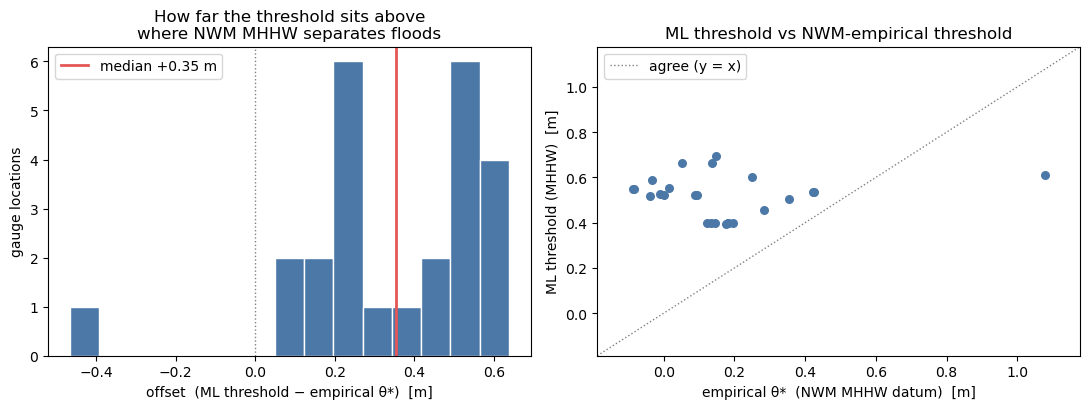

wrote Outputs/Direct_Search/datum_reconciliation.csv


In [9]:
# Visualise the reconciliation: where the ML threshold sits vs where the NWM separates floods.
import matplotlib.pyplot as plt

if len(diag):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    ax[0].hist(diag.offset, bins=15, color="#4C78A8", edgecolor="white")
    ax[0].axvline(0, color="grey", lw=1, ls=":")
    ax[0].axvline(diag.offset.median(), color="#E45756", lw=2,
                  label=f"median {diag.offset.median():+.2f} m")
    ax[0].set(xlabel="offset  (ML threshold − empirical θ*)  [m]", ylabel="gauge locations",
              title="How far the threshold sits above\nwhere NWM MHHW separates floods")
    ax[0].legend()

    lim = [min(diag.theta_star.min(), diag.thr_mhhw.min()) - 0.1,
           max(diag.theta_star.max(), diag.thr_mhhw.max()) + 0.1]
    ax[1].plot(lim, lim, color="grey", ls=":", lw=1, label="agree (y = x)")
    ax[1].scatter(diag.theta_star, diag.thr_mhhw, c="#4C78A8", s=30)
    ax[1].set(xlim=lim, ylim=lim, xlabel="empirical θ*  (NWM MHHW datum)  [m]",
              ylabel="ML threshold (MHHW)  [m]",
              title="ML threshold vs NWM-empirical threshold")
    ax[1].legend()
    fig.tight_layout()
    plt.show()
    print(f"wrote {OUT_DIR}/datum_reconciliation.csv")

## 9. Testing the Calibrated Thresholds on Future Data

Section 6 selects an optimized threshold, **θ**, and evaluates it using the same data. Because the threshold is fitted and tested on the same observations, the reported performance may be overly optimistic.

To obtain a more realistic evaluation, this section divides the data into two time periods:

- **Training period:** NWM data through `2024-12-31`
- **Testing period:** NWM data from `2025-01-01` onward

The optimized threshold is determined using only the training period. It is then applied to the testing period without further adjustment. Because the test data are not used during calibration, they provide a more reliable estimate of how the thresholds may perform on future, unseen data.

The test-period results compare:

- **Before calibration:** performance using the original ML threshold;
- **After calibration:** performance using the optimized threshold fitted to the training data; and
- **Training versus testing performance:** the difference between these results indicates whether the training-period performance was overly optimistic.

When there are too few flood observations or insufficient evidence to estimate a reliable threshold, the method does not perform calibration and retains the original ML threshold.

The **test-set before-and-after results** should be reported as the primary validation results in the manuscript because they provide the most realistic assessment of the calibration method's predictive performance.

In [10]:
TRAIN_END  = "2024-12-31"     # fit theta on everything up to here
TEST_START = "2025-01-01"     # score on this onward -- never seen by the optimizer


def agg_cm(cms):
    tp = sum(c[0] for c in cms); fp = sum(c[1] for c in cms)
    fn = sum(c[2] for c in cms); tn = sum(c[3] for c in cms)
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    tnr  = tn / (tn + fp) if (tn + fp) else 0.0
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "recall": rec, "precision": prec, "F1": f1, "youden": rec + tnr - 1}


def evaluate_location_holdout(loc_id: int):
    thr_row = thresholds.loc[thresholds.location_id == loc_id]
    if thr_row.empty or pd.isna(thr_row.thr_baseline.iloc[0]):
        return None
    base = float(thr_row.thr_baseline.iloc[0])
    lo, hi = float(thr_row.thr_low.iloc[0]), float(thr_row.thr_high.iloc[0])

    twl = load_location_twl(loc_id)
    obs = observed.loc[observed.location_id == loc_id, ["date", "obs_flood"]]
    m = twl.merge(obs, on="date", how="inner")
    tr = m[m.date <= TRAIN_END]
    te = m[m.date >= TEST_START]
    if (len(tr) < MIN_OBSERVED_DAYS or tr.obs_flood.nunique() < 2 or
            len(te) < MIN_OBSERVED_DAYS or te.obs_flood.nunique() < 2):
        return {"location_id": loc_id, "status": "insufficient_split",
                "n_train": len(tr), "n_test": len(te), "thr_baseline": base}

    xtr, ytr = tr.twl.to_numpy(), tr.obs_flood.to_numpy().astype(bool)
    xte, yte = te.twl.to_numpy(), te.obs_flood.to_numpy().astype(bool)

    def result(thr_opt, status):
        return {
            "location_id": loc_id, "n_train": len(tr), "n_test": len(te),
            "n_pos_train": int(ytr.sum()), "n_pos_test": int(yte.sum()),
            "thr_baseline": base, "thr_opt": thr_opt, "thr_shift": thr_opt - base,
            "cm_train_opt": confusion(xtr > thr_opt, ytr),      # in-sample (optimistic)
            "cm_test_base": confusion(xte > base, yte),         # out-of-sample BEFORE
            "cm_test_opt":  confusion(xte > thr_opt, yte),      # out-of-sample AFTER
            "status": status,
        }

    # ---- guards: abstain (keep theta_ML) rather than invent a threshold
    if int(ytr.sum()) < MIN_FLOOD_DAYS:
        return result(base, "abstain_few_floods")

    # ---- FIT on train only
    cand = breakpoint_candidates(xtr, lo, hi)
    if cand.size == 0:
        return result(base, "abstain_no_candidates")
    vals = np.array([objective(*confusion(xtr > t, ytr)) for t in cand])
    thr_opt = float(cand[int(np.argmin(vals) if MINIMISE else np.argmax(vals))])
    if youden(*confusion(xtr > thr_opt, ytr)) < MIN_TRAIN_YOUDEN:
        return result(base, "abstain_no_skill")

    # ---- SCORE on the untouched test period
    return result(thr_opt, "ok")


hold = pd.DataFrame([r for r in (evaluate_location_holdout(l) for l in loc_ids)
                     if r is not None])
split_ok = hold[hold.status.str.startswith(("ok", "abstain"))].copy()   # has a train/test split
hok = hold[hold.status == "ok"].copy()                                  # actually calibrated
hold.to_csv(OUT_DIR / "holdout_validation.csv", index=False)
print(f"{len(hold)} locations; {len(split_ok)} with a usable train/test split "
      f"(train <= {TRAIN_END}, test >= {TEST_START})")
print(f"  calibrated: {len(hok)}   abstained: {len(split_ok) - len(hok)}")
if len(split_ok) > len(hok):
    print(split_ok[split_ok.status != "ok"].status.value_counts().to_string())

if len(split_ok):
    print("\n--- SYSTEM LEVEL (all split locations; abstained keep the ML θ) ---")
    sys_rows = {"TEST BEFORE (ML θ)": agg_cm(split_ok.cm_test_base),
                "TEST AFTER  (calibrated where evidence allows)": agg_cm(split_ok.cm_test_opt)}
    sys_tbl = pd.DataFrame(sys_rows).T
    sys_tbl[["recall", "precision", "F1", "youden"]] = sys_tbl[
        ["recall", "precision", "F1", "youden"]].astype(float).round(3)
    print(sys_tbl.to_string())
    print("\n--- CALIBRATED LOCATIONS ONLY ---")

if len(hok):
    rows = {
        "TEST  BEFORE (ML θ)":   agg_cm(hok.cm_test_base),
        "TEST  AFTER  (fitted)": agg_cm(hok.cm_test_opt),
        "TRAIN AFTER  (in-sample)": agg_cm(hok.cm_train_opt),
    }
    summary = pd.DataFrame(rows).T
    summary[["recall", "precision", "F1", "youden"]] = summary[
        ["recall", "precision", "F1", "youden"]].astype(float).round(3)
    print("\n" + summary.to_string())

    te_f1 = summary.loc["TEST  AFTER  (fitted)", "F1"]
    tr_f1 = summary.loc["TRAIN AFTER  (in-sample)", "F1"]
    print(f"\noptimism gap (train F1 - test F1): {tr_f1 - te_f1:+.3f}")
    print(f"median θ shift: {hok.thr_shift.median():+.3f} m  "
          f"(down at {(hok.thr_shift < 0).sum()}/{len(hok)}, up at {(hok.thr_shift > 0).sum()})")
hok.head(10)

336 locations; 175 with a usable train/test split (train <= 2024-12-31, test >= 2025-01-01)
  calibrated: 111   abstained: 64
status
abstain_few_floods       58
abstain_no_skill          5
abstain_no_candidates     1

--- SYSTEM LEVEL (all split locations; abstained keep the ML θ) ---
                                                   TP      FP      FN       TN  recall  precision     F1  youden
TEST BEFORE (ML θ)                              289.0  1686.0  1117.0  56221.0   0.206      0.146  0.171   0.176
TEST AFTER  (calibrated where evidence allows)  889.0  1943.0   517.0  55964.0   0.632      0.314  0.420   0.599

--- CALIBRATED LOCATIONS ONLY ---

                              TP      FP     FN       TN  recall  precision     F1  youden
TEST  BEFORE (ML θ)        236.0  1130.0  953.0  47481.0   0.198      0.173  0.185   0.175
TEST  AFTER  (fitted)      836.0  1387.0  353.0  47224.0   0.703      0.376  0.490   0.675
TRAIN AFTER  (in-sample)  1767.0  1334.0  560.0  43624.0   0.759  

,location_id,n_train,n_test,n_pos_train,n_pos_test,thr_baseline,thr_opt,thr_shift,cm_train_opt,cm_test_base,cm_test_opt,status
0,596,458,485,80.0,61.0,0.664776,0.107,-0.557776,"(62, 35, 18, 343)","(0, 0, 61, 424)","(32, 9, 29, 415)",ok
1,539,458,485,78.0,25.0,0.693485,0.193,-0.500485,"(69, 25, 9, 355)","(0, 0, 25, 460)","(19, 21, 6, 439)",ok
2,1431,458,477,44.0,29.0,0.665452,0.161,-0.504452,"(43, 22, 1, 392)","(0, 0, 29, 448)","(28, 31, 1, 417)",ok
3,580,458,485,8.0,51.0,0.611686,1.112,0.500314,"(8, 12, 0, 438)","(45, 48, 6, 386)","(42, 16, 9, 418)",ok
4,508,74,58,37.0,23.0,0.409510,-0.111,-0.520510,"(36, 34, 1, 3)","(0, 0, 23, 35)","(23, 33, 0, 2)",ok
5,591,458,485,50.0,9.0,0.586980,0.031,-0.555980,"(43, 30, 7, 378)","(0, 0, 9, 476)","(8, 11, 1, 465)",ok
6,587,458,485,48.0,10.0,0.603362,0.325,-0.278362,"(37, 14, 11, 396)","(0, 0, 10, 475)","(5, 7, 5, 468)",ok
7,1226,458,485,33.0,12.0,0.544297,0.497,-0.047297,"(24, 9, 9, 416)","(5, 5, 7, 468)","(6, 14, 6, 459)",ok
8,80,458,485,26.0,27.0,0.395442,0.270,-0.125442,"(14, 7, 12, 425)","(4, 0, 23, 458)","(14, 11, 13, 447)",ok
9,1030,458,485,27.0,18.0,0.551609,0.051,-0.500609,"(24, 16, 3, 415)","(0, 0, 18, 467)","(16, 9, 2, 458)",ok


## 10. Cost-weight tuning (the recall ↔ precision dial)

`COST_FN / COST_FP` is the only dial trading missed floods against false alarms. At 5:1
the full run reached 76% recall but only 35% precision out-of-sample. Here we sweep the
ratio, **refit θ on train** for each, and score on the **untouched test** period, so you
can pick the operational point.

For speed the threshold curve (TP/FP/FN/TN at every breakpoint) is computed **once per
location** by vectorised counting; each ratio is then just an `argmin` over that curve.

In [11]:
COST_RATIOS = [1, 2, 3, 5, 8, 12, 20]      # COST_FN / COST_FP, with COST_FP fixed at 1


def threshold_curve(x: np.ndarray, y: np.ndarray):
    '''Vectorised: TP/FP/FN/TN at every breakpoint candidate. Returns (cands, TP, FP, FN, TN).'''
    order = np.argsort(x, kind="mergesort")
    xs, ys = x[order], y[order]
    u = np.unique(xs)
    cands = np.concatenate([[u[0] - EPS], (u[:-1] + u[1:]) / 2, [u[-1] + EPS]])
    xs_pos = xs[ys]                                   # positives, still sorted
    P, N = int(ys.sum()), int((~ys).sum())
    n_gt  = len(xs) - np.searchsorted(xs, cands, side="right")      # predicted flood
    TP    = P - np.searchsorted(xs_pos, cands, side="right")
    FP    = n_gt - TP
    FN    = P - TP
    TN    = N - FP
    return cands, TP, FP, FN, TN


def prepare_holdout_arrays():
    '''Per-location train/test arrays + the train threshold curve (computed once).'''
    data = {}
    for loc in loc_ids:
        row = thresholds.loc[thresholds.location_id == loc]
        if row.empty or pd.isna(row.thr_baseline.iloc[0]):
            continue
        base = float(row.thr_baseline.iloc[0])
        lo, hi = float(row.thr_low.iloc[0]), float(row.thr_high.iloc[0])
        twl = load_location_twl(loc)
        obs = observed.loc[observed.location_id == loc, ["date", "obs_flood"]]
        m = twl.merge(obs, on="date", how="inner")
        tr, te = m[m.date <= TRAIN_END], m[m.date >= TEST_START]
        if (len(tr) < MIN_OBSERVED_DAYS or tr.obs_flood.nunique() < 2 or
                len(te) < MIN_OBSERVED_DAYS or te.obs_flood.nunique() < 2):
            continue
        xtr, ytr = tr.twl.to_numpy(), tr.obs_flood.to_numpy().astype(bool)
        xte, yte = te.twl.to_numpy(), te.obs_flood.to_numpy().astype(bool)
        cands, TP, FP, FN, TN = threshold_curve(xtr, ytr)
        if CONSTRAIN_TO_RANGE and np.isfinite(lo) and np.isfinite(hi):
            keep = (cands >= lo) & (cands <= hi)
            if keep.any():
                cands, TP, FP, FN, TN = cands[keep], TP[keep], FP[keep], FN[keep], TN[keep]
        data[loc] = dict(base=base, xte=xte, yte=yte, cands=cands, FP=FP, FN=FN)
    return data


HD = prepare_holdout_arrays()
print(f"{len(HD)} locations with a usable train/test split\n")

sweep = []
for ratio in COST_RATIOS:
    cms_opt, shifts = [], []
    for loc, d in HD.items():
        cost = ratio * d["FN"] + d["FP"]              # COST_FP == 1
        thr_opt = float(d["cands"][int(np.argmin(cost))])
        cms_opt.append(confusion(d["xte"] > thr_opt, d["yte"]))
        shifts.append(thr_opt - d["base"])
    a = agg_cm(cms_opt)
    a.update({"COST_FN:COST_FP": f"{ratio}:1", "median_shift_m": float(np.median(shifts))})
    sweep.append(a)

sw = pd.DataFrame(sweep).set_index("COST_FN:COST_FP")
sw_show = sw[["TP", "FP", "FN", "recall", "precision", "F1", "youden", "median_shift_m"]].copy()
sw_show[["recall", "precision", "F1", "youden"]] = sw_show[
    ["recall", "precision", "F1", "youden"]].astype(float).round(3)
sw_show["median_shift_m"] = sw_show["median_shift_m"].round(3)
print("OUT-OF-SAMPLE performance vs cost ratio (theta refit on train for each):")
print(sw_show.to_string())

best_f1 = sw.F1.astype(float).idxmax(); best_j = sw.youden.astype(float).idxmax()
print(f"\nbest F1     at COST_FN:COST_FP = {best_f1}  (F1={sw.F1.astype(float).max():.3f})")
print(f"best Youden at COST_FN:COST_FP = {best_j}  (J ={sw.youden.astype(float).max():.3f})")
sw.to_csv(OUT_DIR / "cost_sweep.csv")

175 locations with a usable train/test split

OUT-OF-SAMPLE performance vs cost ratio (theta refit on train for each):
                   TP    FP   FN  recall  precision     F1  youden  median_shift_m
COST_FN:COST_FP                                                                   
1:1               723   657  683   0.514      0.524  0.519   0.503          -0.188
2:1               852  1012  554   0.606      0.457  0.521   0.588          -0.209
3:1               935  1380  471   0.665      0.404  0.503   0.641          -0.256
5:1              1071  1965  335   0.762      0.353  0.482   0.728          -0.327
8:1              1123  2644  283   0.799      0.298  0.434   0.753          -0.350
12:1             1156  3177  250   0.822      0.267  0.403   0.767          -0.364
20:1             1185  3861  221   0.843      0.235  0.367   0.776          -0.375

best F1     at COST_FN:COST_FP = 2:1  (F1=0.521)
best Youden at COST_FN:COST_FP = 20:1  (J =0.776)


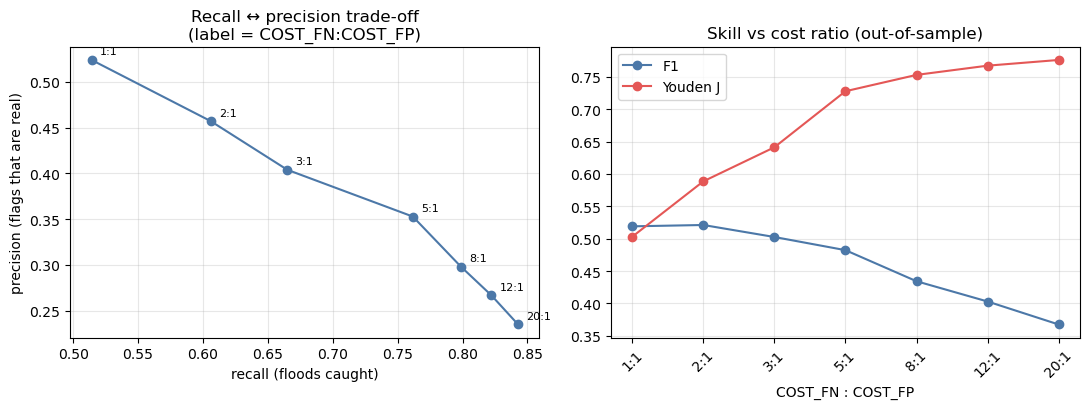

wrote Outputs/Direct_Search/cost_sweep.csv


In [12]:
# Trade-off curves: pick the operational point.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
r = sw.recall.astype(float); p = sw.precision.astype(float)
ax[0].plot(r, p, "-o", color="#4C78A8")
for lab, xi, yi in zip(sw.index, r, p):
    ax[0].annotate(lab, (xi, yi), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax[0].set(xlabel="recall (floods caught)", ylabel="precision (flags that are real)",
          title="Recall ↔ precision trade-off\n(label = COST_FN:COST_FP)")
ax[0].grid(alpha=.3)

x = np.arange(len(sw))
ax[1].plot(x, sw.F1.astype(float), "-o", label="F1", color="#4C78A8")
ax[1].plot(x, sw.youden.astype(float), "-o", label="Youden J", color="#E45756")
ax[1].set_xticks(x); ax[1].set_xticklabels(sw.index, rotation=45)
ax[1].set(xlabel="COST_FN : COST_FP", title="Skill vs cost ratio (out-of-sample)")
ax[1].legend(); ax[1].grid(alpha=.3)
fig.tight_layout()
plt.show()
print(f"wrote {OUT_DIR}/cost_sweep.csv")